In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rohitgrewal/airlines-flights-data/airlines_flights_data.csv


# Data Cleaning

In [7]:
df = pd.read_csv("/kaggle/input/datasets/rohitgrewal/airlines-flights-data/airlines_flights_data.csv")
df.set_index('index', inplace=True)
df.head(5)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
index,,,,,,,,,,,
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [8]:
df.isna().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


In [10]:
df['stops'].describe()

count     300153
unique         3
top          one
freq      250863
Name: stops, dtype: object

In [11]:
df['stops'].unique()

array(['zero', 'one', 'two_or_more'], dtype=object)

In [12]:
mapping = {'zero': 0, 'one': 1, 'two_or_more': 2}
df['stops'] = df['stops'].map(mapping)
df.head(5)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
index,,,,,,,,,,,
0,SpiceJet,SG-8709,Delhi,Evening,0,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,0,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,0,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,0,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,0,Morning,Mumbai,Economy,2.33,1,5955


# Exploratory Data Analysis (EDA)

In [13]:
df.groupby('airline')['price'].mean()

airline
AirAsia       4091.072742
Air_India    23507.019112
GO_FIRST      5652.007595
Indigo        5324.216303
SpiceJet      6179.278881
Vistara      30396.536302
Name: price, dtype: float64

In [14]:
df.groupby('destination_city')['stops'].mean()

destination_city
Bangalore    0.937260
Chennai      0.985781
Delhi        0.838668
Hyderabad    0.952722
Kolkata      0.980478
Mumbai       0.886644
Name: stops, dtype: float64

In [15]:
df.corr(numeric_only=True)

,stops,duration,days_left,price
stops,1.000000,0.468059,-0.008540,0.119648
duration,0.468059,1.000000,-0.039157,0.204222
days_left,-0.008540,-0.039157,1.000000,-0.091949
price,0.119648,0.204222,-0.091949,1.000000


In [16]:
df.groupby('source_city')['departure_time'].agg(
    most_common = lambda x: x.value_counts().idxmax(),
    most_count = lambda x: x.value_counts().max(),
    least_common = lambda y: y.value_counts().idxmin(),
    least_count = lambda y: y.value_counts().min()
)

,most_common,most_count,least_common,least_count
source_city,,,,
Bangalore,Evening,14243,Late_Night,457
Chennai,Morning,10550,Late_Night,72
Delhi,Evening,16790,Late_Night,357
Hyderabad,Morning,9923,Late_Night,38
Kolkata,Morning,12065,Late_Night,114
Mumbai,Early_Morning,14955,Late_Night,268


In [17]:
df.groupby('destination_city')['arrival_time'].agg(
    most_common = lambda x: x.value_counts().idxmax(),
    most_count = lambda x: x.value_counts().max(),
    least_common = lambda y: y.value_counts().idxmin(),
    least_count = lambda y: y.value_counts().min()
)

,most_common,most_count,least_common,least_count
destination_city,,,,
Bangalore,Night,16059,Early_Morning,1823
Chennai,Night,13183,Late_Night,975
Delhi,Night,16044,Early_Morning,536
Hyderabad,Night,14022,Late_Night,555
Kolkata,Evening,17917,Late_Night,1230
Mumbai,Night,21742,Late_Night,1769


In [18]:
df.groupby('airline')['departure_time'].agg(
    most_common = lambda x: x.value_counts().idxmax(),
    most_count = lambda x: x.value_counts().max(),
    least_common = lambda y: y.value_counts().idxmin(),
    least_count = lambda y: y.value_counts().min()
)

,most_common,most_count,least_common,least_count
airline,,,,
AirAsia,Early_Morning,3692,Late_Night,143
Air_India,Early_Morning,19867,Late_Night,291
GO_FIRST,Early_Morning,6103,Late_Night,146
Indigo,Morning,11491,Late_Night,726
SpiceJet,Early_Morning,2728,Afternoon,1193
Vistara,Morning,33904,Afternoon,17550


In [19]:
df.groupby('airline')['arrival_time'].agg(
    most_common = lambda x: x.value_counts().idxmax(),
    most_count = lambda x: x.value_counts().max(),
    least_common = lambda y: y.value_counts().idxmin(),
    least_count = lambda y: y.value_counts().min()
)

,most_common,most_count,least_common,least_count
airline,,,,
AirAsia,Late_Night,3491,Early_Morning,1407
Air_India,Night,24552,Late_Night,2090
GO_FIRST,Night,7053,Early_Morning,2705
Indigo,Night,12701,Early_Morning,2537
SpiceJet,Night,3062,Late_Night,456
Vistara,Night,40693,Late_Night,1731


## Question: Which Airline has the best Flight Hour to Profit Ratio

In [38]:
hour_profits = df.groupby("airline", as_index=False).agg(
    total_price=("price", "sum"),
    total_duration=("duration", "sum"),
    total_flights=("airline", "size")
)

hour_profits["profit_per_hour"] = (
    hour_profits["total_price"] / hour_profits["total_duration"]
)

In [39]:
hour_profits

,airline,total_price,total_duration,total_flights,profit_per_hour
0,AirAsia,65858089,143943.72,16098,457.526657
1,Air_India,1901529790,1254168.60,80892,1516.167595
2,GO_FIRST,130973972,202888.42,23173,645.546808
3,Indigo,229580207,249888.88,43120,918.729185
4,SpiceJet,55681482,113356.28,9011,491.207739
5,Vistara,3886470735,1703930.16,127859,2280.886169


<Figure size 1000x600 with 0 Axes>

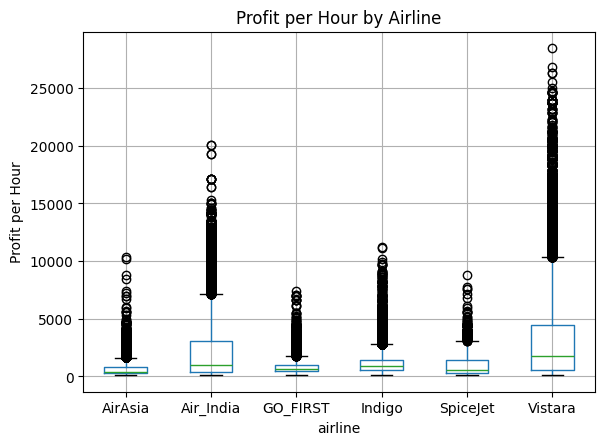

In [53]:
import squarify
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df["profit_per_hour"] = df["price"] / df["duration"]

df.boxplot(column="profit_per_hour", by="airline")

plt.title("Profit per Hour by Airline")
plt.suptitle("")  # removes pandas automatic subtitle
plt.ylabel("Profit per Hour")

plt.show()

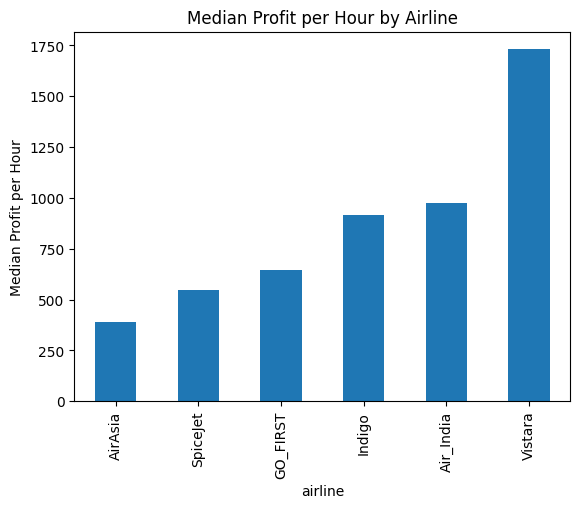

In [55]:
medians = df.groupby("airline")["profit_per_hour"].median()

medians.sort_values().plot(kind="bar")

plt.ylabel("Median Profit per Hour")
plt.title("Median Profit per Hour by Airline")

plt.show()

In [41]:
market_share = df.groupby("airline", as_index=False).agg(
    total_price=("price", "sum"),
    total_duration=("duration", "sum"),
    total_flights=("airline", "size")
)

market_share["profit_per_hour"] = (
    market_share["total_price"] / market_share["total_duration"]
)

market_share["flight_market_share"] = (
    market_share["total_flights"] / market_share["total_flights"].sum()
)

market_share["revenue_market_share"] = (
    market_share["total_price"] / market_share["total_price"].sum()
)

In [42]:
market_share

,airline,total_price,total_duration,total_flights,profit_per_hour,flight_market_share,revenue_market_share
0,AirAsia,65858089,143943.72,16098,457.526657,0.053633,0.010504
1,Air_India,1901529790,1254168.60,80892,1516.167595,0.269503,0.303270
2,GO_FIRST,130973972,202888.42,23173,645.546808,0.077204,0.020889
3,Indigo,229580207,249888.88,43120,918.729185,0.143660,0.036615
4,SpiceJet,55681482,113356.28,9011,491.207739,0.030021,0.008880
5,Vistara,3886470735,1703930.16,127859,2280.886169,0.425979,0.619842


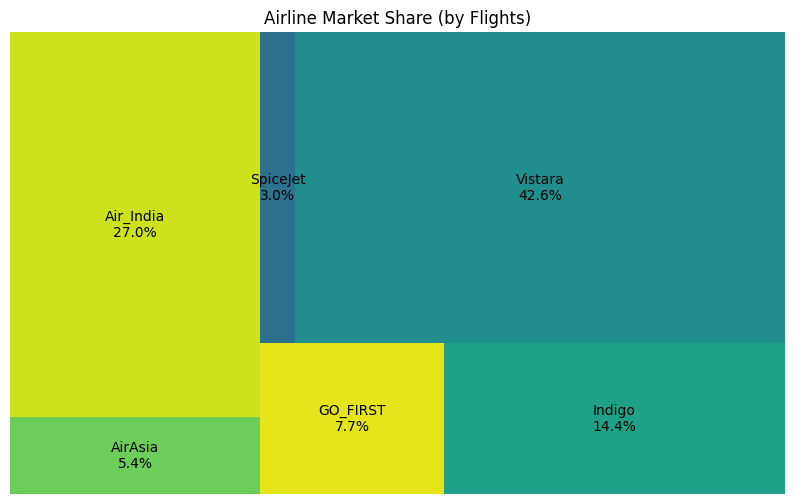

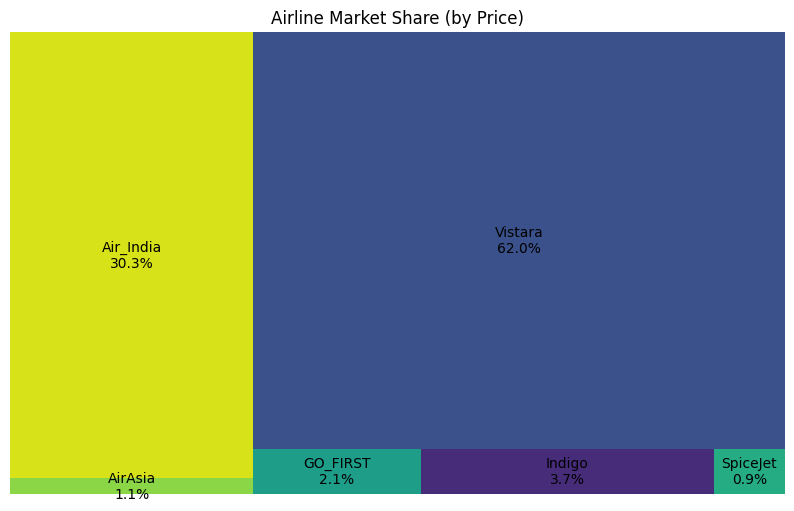

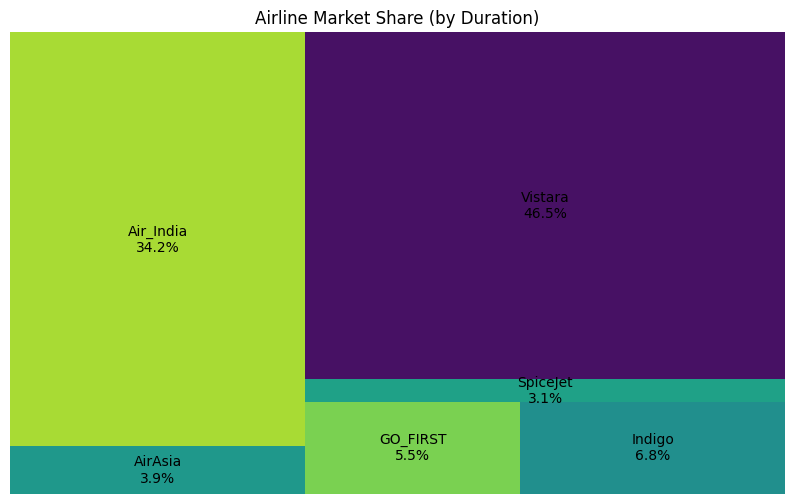

In [51]:

plt.figure(figsize=(10,6))


market_share["market_share"] = (
    market_share["total_flights"] /
    market_share["total_flights"].sum()
)

labels = [
    f"{airline}\n{share:.1%}"
    for airline, share in zip(
        market_share["airline"],
        market_share["market_share"]
    )
]

squarify.plot(
    sizes=market_share["total_flights"],
    label=labels
)



plt.title("Airline Market Share (by Flights)")
plt.axis("off")


##################

plt.figure(figsize=(10,6))


market_share["market_share"] = (
    market_share["total_price"] /
    market_share["total_price"].sum()
)

labels = [
    f"{airline}\n{share:.1%}"
    for airline, share in zip(
        market_share["airline"],
        market_share["market_share"]
    )
]

squarify.plot(
    sizes=market_share["total_price"],
    label=labels
)



plt.title("Airline Market Share (by Price)")
plt.axis("off")

###############

plt.figure(figsize=(10,6))


market_share["market_share"] = (
    market_share["total_duration"] /
    market_share["total_duration"].sum()
)

labels = [
    f"{airline}\n{share:.1%}"
    for airline, share in zip(
        market_share["airline"],
        market_share["market_share"]
    )
]

squarify.plot(
    sizes=market_share["total_duration"],
    label=labels
)



plt.title("Airline Market Share (by Duration)")
plt.axis("off")


plt.show()

In [58]:
class_counts = df.groupby(["airline", "class"]).size().unstack()
class_counts.fillna(0, inplace=True)
class_counts

class,Business,Economy
airline,,
AirAsia,0.0,16098.0
Air_India,32898.0,47994.0
GO_FIRST,0.0,23173.0
Indigo,0.0,43120.0
SpiceJet,0.0,9011.0
Vistara,60589.0,67270.0


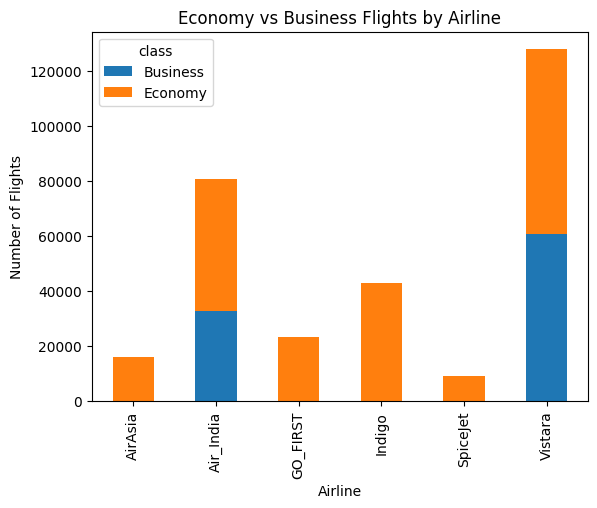

In [59]:
class_counts.plot(kind="bar", stacked=True)

plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.title("Economy vs Business Flights by Airline")

plt.show()

## Finding: Business vs Economy

Through Exploratory Data Analysis, it has been found to be true that the top two airlines in terms of price/profit and flight count, Vistara and Air_India, are the **only** airlines in the dataset that have business class flights. This can easily skew average profit margins due to the standard higher prices of business class flying. To find out more information about the other airlines and how they compare, I've decided to remove the business class from the equation and focus solely on economy class flights. This may elucidate further features and correlations for price/profit that were hidden by class, and that may effect smaller or economy-only airlines.

In [66]:
economy_df = df[df["class"] == "Economy"].copy()

economy_df["profit_per_hour"] = economy_df["price"] / economy_df["duration"]

economy_profits = economy_df.groupby("airline", as_index=False).agg(
    total_price=("price", "sum"),
    total_duration=("duration", "sum"),
    total_flights=("airline", "size")
)

economy_profits["profit_per_hour"] = (
    economy_profits["total_price"] / economy_profits["total_duration"]
)

economy_profits

,airline,total_price,total_duration,total_flights,profit_per_hour
0,AirAsia,65858089,143943.72,16098,457.526657
1,Air_India,351012862,772709.10,47994,454.262622
2,GO_FIRST,130973972,202888.42,23173,645.546808
3,Indigo,229580207,249888.88,43120,918.729185
4,SpiceJet,55681482,113356.28,9011,491.207739
5,Vistara,525173099,904218.21,67270,580.803498


<Figure size 1000x600 with 0 Axes>

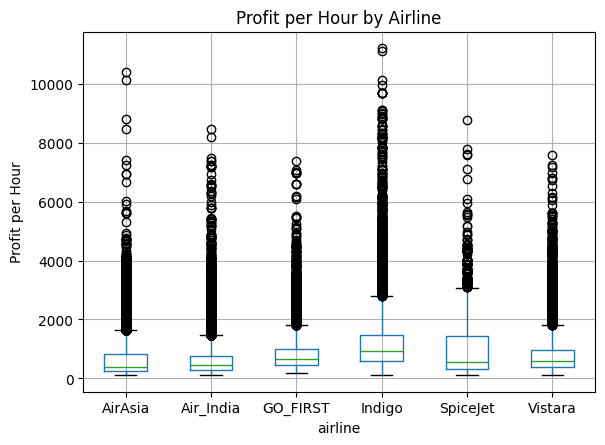

In [79]:
plt.figure(figsize=(10,6))


economy_df.boxplot(column="profit_per_hour", by="airline")

plt.title("Profit per Hour by Airline")
plt.suptitle("")  # removes pandas automatic subtitle
plt.ylabel("Profit per Hour")

plt.show()

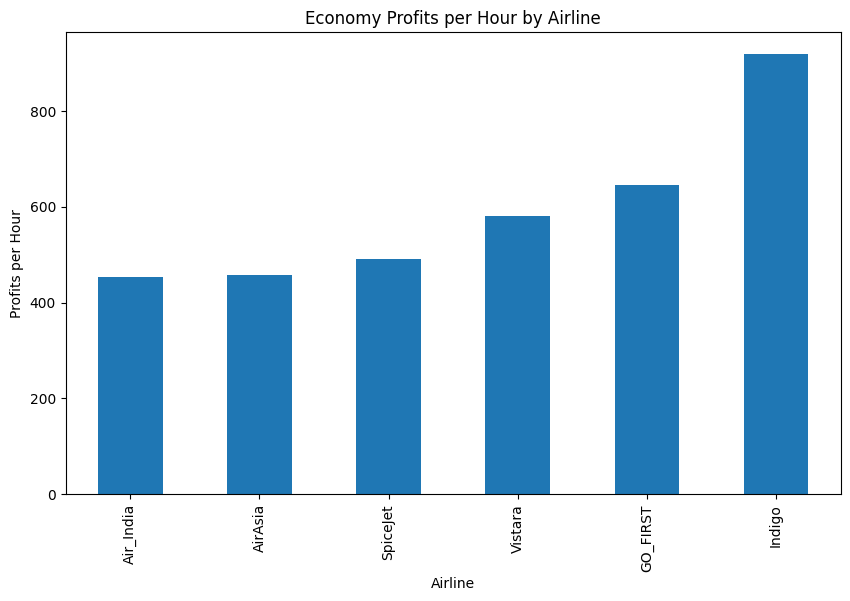

In [73]:
plt.figure(figsize=(10,6))

economy_profits.set_index("airline")["profit_per_hour"] \
    .sort_values() \
    .plot(kind="bar")

plt.xlabel("Airline")
plt.ylabel("Profits per Hour")
plt.title("Economy Profits per Hour by Airline")

plt.show()

In [76]:
eco_market_share = economy_df.groupby("airline", as_index=False).agg(
    total_price=("price", "sum"),
    total_duration=("duration", "sum"),
    total_flights=("airline", "size")
)

eco_market_share["profit_per_hour"] = (
    eco_market_share["total_price"] / eco_market_share["total_duration"]
)

eco_market_share["flight_market_share"] = (
    eco_market_share["total_flights"] / eco_market_share["total_flights"].sum()
)

eco_market_share["revenue_market_share"] = (
    eco_market_share["total_price"] / eco_market_share["total_price"].sum()
)
eco_market_share

,airline,total_price,total_duration,total_flights,profit_per_hour,flight_market_share,revenue_market_share
0,AirAsia,65858089,143943.72,16098,457.526657,0.077894,0.048486
1,Air_India,351012862,772709.10,47994,454.262622,0.232230,0.258425
2,GO_FIRST,130973972,202888.42,23173,645.546808,0.112128,0.096426
3,Indigo,229580207,249888.88,43120,918.729185,0.208646,0.169023
4,SpiceJet,55681482,113356.28,9011,491.207739,0.043602,0.040994
5,Vistara,525173099,904218.21,67270,580.803498,0.325501,0.386646


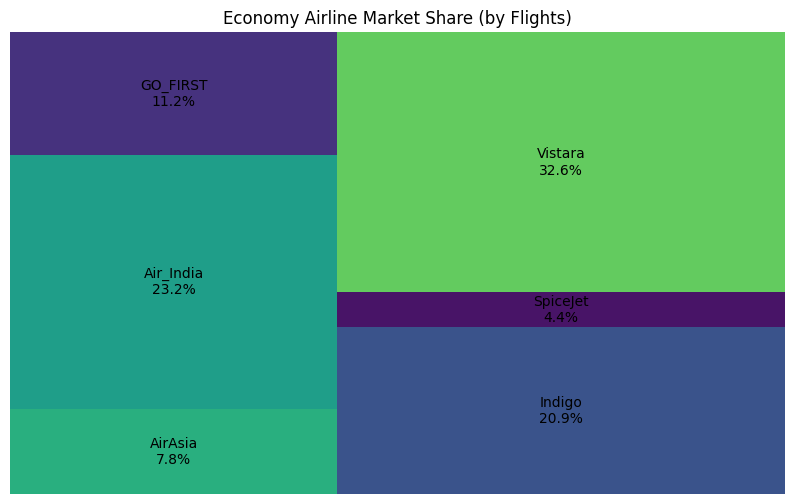

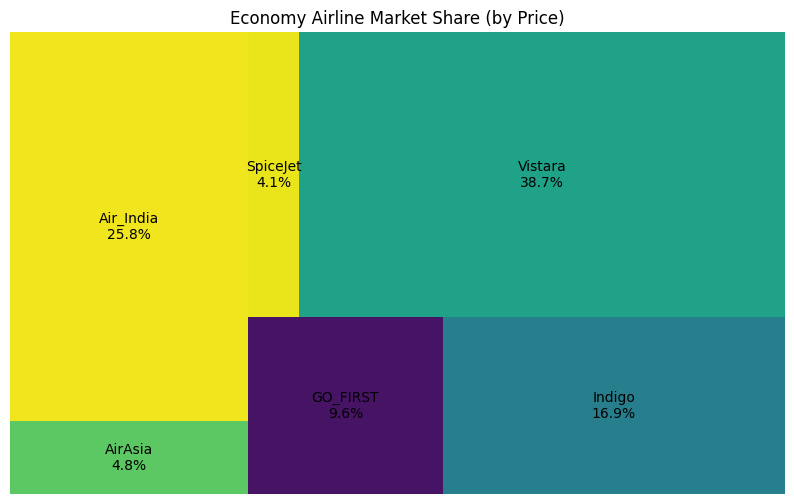

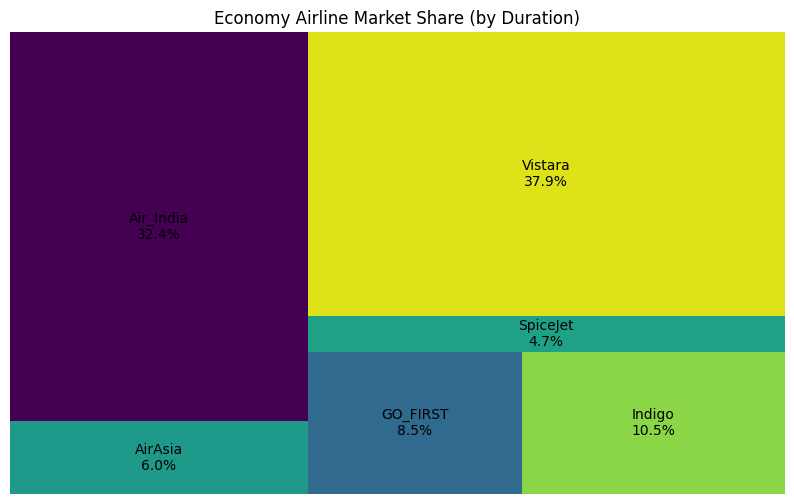

In [77]:

plt.figure(figsize=(10,6))


eco_market_share["market_share"] = (
    eco_market_share["total_flights"] /
    eco_market_share["total_flights"].sum()
)

labels = [
    f"{airline}\n{share:.1%}"
    for airline, share in zip(
        eco_market_share["airline"],
        eco_market_share["market_share"]
    )
]

squarify.plot(
    sizes=eco_market_share["total_flights"],
    label=labels
)



plt.title("Economy Airline Market Share (by Flights)")
plt.axis("off")


##################

plt.figure(figsize=(10,6))


eco_market_share["market_share"] = (
    eco_market_share["total_price"] /
    eco_market_share["total_price"].sum()
)

labels = [
    f"{airline}\n{share:.1%}"
    for airline, share in zip(
        eco_market_share["airline"],
        eco_market_share["market_share"]
    )
]

squarify.plot(
    sizes=eco_market_share["total_price"],
    label=labels
)



plt.title("Economy Airline Market Share (by Price)")
plt.axis("off")

###############

plt.figure(figsize=(10,6))


eco_market_share["market_share"] = (
    eco_market_share["total_duration"] /
    eco_market_share["total_duration"].sum()
)

labels = [
    f"{airline}\n{share:.1%}"
    for airline, share in zip(
        eco_market_share["airline"],
        eco_market_share["market_share"]
    )
]

squarify.plot(
    sizes=eco_market_share["total_duration"],
    label=labels
)



plt.title("Economy Airline Market Share (by Duration)")
plt.axis("off")


plt.show()

23.3 of the 62% Vistara's Market Share by price is dependent on Business Class flights. This is about a 37.7% decrease when looking only at Economy Class data.

## Question: How Much does Business Class increase Revenue per Hour?

### How does the "Days Left" Feature affect the dataset?

In [80]:
df['days_left'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])